In [1]:
# A manufacturing company wants to predict machine failures using real-time IoT sensor data and reduce downtime.

# We will build:

#  Azure ML Workspace
#  Training Pipeline
#  Retraining Automation
#  Real-time API
#  Alert System
#  Dashboard
#  AIOps Monitoring

In [2]:
# IoT Sensors → Azure Blob Storage / IoT Hub
#         ↓
# Azure ML Pipeline
# (Data Prep → Train → Evaluate → Register Model)
#         ↓
# Managed Online Endpoint
#         ↓
# API /predict-failure
#         ↓
# Alerts + Dashboard + Monitoring

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [4]:
df = pd.read_csv("machine_sensor_data.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)



First 5 Rows
             Timestamp MachineID  Temperature  Vibration  Pressure  Humidity  \
0  2024-01-01 00:00:00       M01           78   0.891330        40        51   
1  2024-01-01 00:05:00       M02           59   0.708022        21        49   
2  2024-01-01 00:10:00       M02           67   0.592267        24        37   
3  2024-01-01 00:15:00       M02           77   0.846787        25        58   
4  2024-01-01 00:20:00       M03           84   0.645532        31        37   

   Failure  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape:
(500, 7)

Columns:
Index(['Timestamp', 'MachineID', 'Temperature', 'Vibration', 'Pressure',
       'Humidity', 'Failure'],
      dtype='object')


In [5]:
# Convert Timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Extract Hour
df["Hour"] = df["Timestamp"].dt.hour

# Encode MachineID
le = LabelEncoder()
df["MachineID"] = le.fit_transform(df["MachineID"])


In [6]:
X = df[["MachineID", "Temperature", "Vibration", "Pressure", "Humidity", "Hour"]]
y = df["Failure"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = model.predict(X_test)

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))





Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
[[90  0]
 [ 0 10]]


In [8]:
joblib.dump(model, "machine_failure_model.pkl")

print("\nModel Saved Successfully")



Model Saved Successfully


In [9]:
# ==========================================
# STEP 9: Manual Prediction (NEW INPUT)
# ==========================================

# Example:
# MachineID = M01
# Temperature = 92
# Vibration = 0.88
# Pressure = 44
# Humidity = 51
# Hour = 14

machine = "M01"

machine_encoded = le.transform([machine])[0]

new_data = pd.DataFrame([{
    "MachineID": machine_encoded,
    "Temperature": 92,
    "Vibration": 0.88,
    "Pressure": 44,
    "Humidity": 51,
    "Hour": 14
}])

# Prediction
prediction = model.predict(new_data)[0]

# Probability
probability = model.predict_proba(new_data)[0][1]

print("\n==============================")
print("PREDICTION OUTPUT")
print("==============================")

print("Failure Prediction:", prediction)

if prediction == 1:
    print("Status: Machine Failure Likely")
else:
    print("Status: Normal Machine")

print("Failure Probability:", round(probability * 100, 2), "%")

# ==========================================
# STEP 10: Multiple Predictions
# ==========================================

sample_data = X_test.head(10)

predictions = model.predict(sample_data)

print("\nMultiple Sample Predictions:")
print(predictions)


PREDICTION OUTPUT
Failure Prediction: 1
Status: Machine Failure Likely
Failure Probability: 91.0 %

Multiple Sample Predictions:
[0 1 0 0 0 0 0 0 0 0]



Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



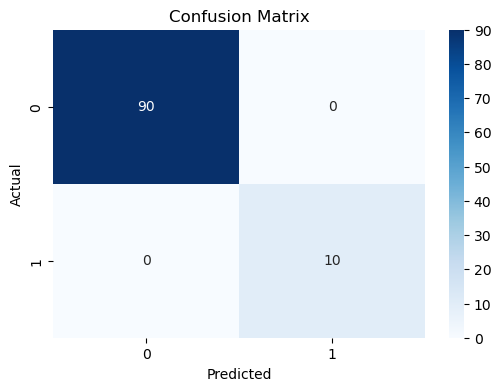

['predictive_model.pkl']

In [12]:

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day

# Encode MachineID
le = LabelEncoder()
df["MachineID"] = le.fit_transform(df["MachineID"])

# ==========================================================
# STEP 4: Feature Selection
# ==========================================================

X = df[[
    "MachineID",
    "Temperature",
    "Vibration",
    "Pressure",
    "Humidity",
    "Hour"
]]

y = df["Failure"]

# ==========================================================
# STEP 5: Split Data
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# STEP 6: Train Model
# ==========================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================================
# STEP 7: Test Prediction
# ==========================================================

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# STEP 8: Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# STEP 9: Save Model
# ==========================================================

joblib.dump(model, "predictive_model.pkl")

